In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from bayspecdec.spectrum_gen import *
import bayspecdec as bsd

from functools import partial

In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
Array = np.ndarray[tuple[int], np.dtype(np.float32)]

In [4]:
BIN_SIZE: float = 1e-1
MIN: float = 0
MAX: float = 10

In [5]:
DET_AX: Array = np.arange(MIN, MAX, BIN_SIZE)
PEAK: Array = np.zeros_like(DET_AX)
PEAK += lorentzian(DET_AX, 5, 0.5, 1)

In [6]:
SIGNAL: Array = np.zeros_like(DET_AX)
SIGNAL[bin_idx(DET_AX, 1)] += 1
SIGNAL[bin_idx(DET_AX, 7)] += 2
SIGNAL[bin_idx(DET_AX, 4)] += 2
# SIGNAL[bin_idx(DET_AX, 6)] += 2

BLURRED: Array = sp.signal.convolve(SIGNAL, PEAK, mode="full")[
    len(DET_AX) // 2 : -len(DET_AX) // 2 + 1
]

y = draw_spectrum(BLURRED, dose=100_000).astype(np.float64)
y /= y.max()

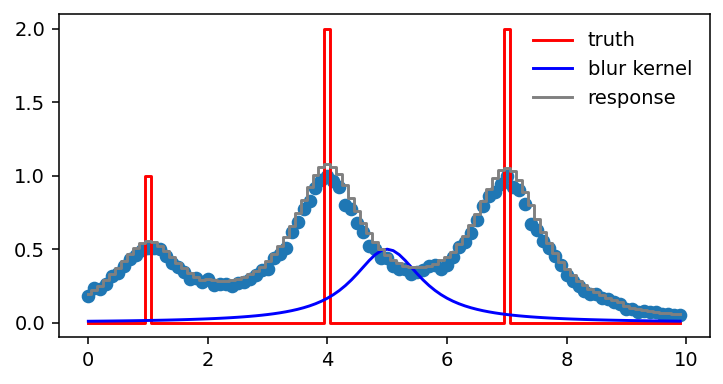

In [7]:
plt.step(DET_AX, SIGNAL, where="mid", label="truth", color="red")
plt.plot(DET_AX, PEAK, label="blur kernel", color="blue")
plt.step(DET_AX, BLURRED, where="mid", label="response", color="gray")
plt.scatter(DET_AX, y)
fig = plt.gcf()
fig.set_size_inches(6, 3)
fig.set_dpi(140)
plt.legend(frameon=False)

In [8]:
from typing import Iterable


class BlurKernel:
    name: str = "BlurKernel"
    n_parameters_per_basis: int = 1

    def evaluate(self, x: Array, params: Iterable[Array]) -> Array:
        (μ,) = params
        evals = []
        for μi in μ:
            peak = lorentzian(x, μi, 0.5, 1)
            peak /= peak.max()
            evals.append(peak)
        return np.stack(evals)

In [9]:
from numba.experimental.jitclass.decorators import jitclass


class Parameterization:
    def __init__(self, K: int):
        self.K = K
        self.ndim = 2 * K

    def pack(self, structured: tuple[Array, Array, Array]) -> Array:
        I, μ = structured
        θ = np.empty(self.ndim)
        θ[: self.K] = I
        θ[self.K : 2 * self.K] = μ
        # θ[2 * self.K :] = σ
        return θ

    def unpack(self, θ: Array) -> tuple[Array, Array, Array]:
        I: Array = θ[..., : self.K]
        μ: Array = θ[..., self.K : 2 * self.K]
        # σ: Array = θ[..., 2 * self.K :]
        return (I, μ)  # , σ)

    def to_z(self, θ: Array) -> Array:
        z = θ.copy()
        # z[..., : self.K] = np.log(z[..., : self.K])
        return z

    def from_z(self, z: Array) -> Array:
        θ = z.copy()
        # θ[..., : self.K] = np.exp(θ[..., : self.K])
        return θ

    def log_jacobian(self, θ: Array) -> float:
        return 1
        I, μ, σ = self.unpack(θ)
        return float(np.sum(np.log(I)) + np.sum(np.log(θ)))

In [10]:
class LorentzPrior:
    def __init__(self, amplitudes, centers):  # , widths):
        self.amplitudes = amplitudes
        self.centers = centers
        # self.widths = widths

    def sample(self, rng, parameterization) -> Array:
        K: int = parameterization.K
        I: Array = self.amplitudes.sample(rng, K)
        μ: Array = self.centers.sample(rng, K)
        # σ: Array = self.widths.sample(rng, K)
        # print(f"I: {I}, μ: {μ}, σ: {σ}")
        # for Ii, μi, σi in zip(I, μ, σ):
        #     plt.plot(lorentzian(DET_AX, μi, σi, Ii))
        # plt.show()
        return parameterization.pack((I, μ))

    def log_prob(self, θ, parameterization) -> float:
        I, μ = parameterization.unpack(θ)
        lp_I = np.sum(self.amplitudes.log_prob(I))
        lp_μ = np.sum(self.centers.log_prob(μ))
        # lp_σ = np.sum(self.widths.log_prob(σ))
        return float(lp_I + lp_μ)  # + lp_σ)

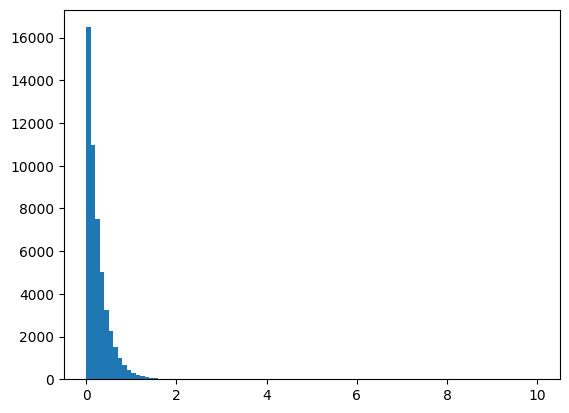

In [11]:
plt.hist(
    bsd.GammaPrior(1, 4).sample(np.random.default_rng(), 50_000),
    range=(0, 10),
    bins=100,
);

In [12]:
lorentz_prior = LorentzPrior(
    amplitudes=bsd.GammaPrior(1, 4),
    centers=bsd.UniformPrior(1, 9),
    # widths=bsd.GammaPrior(5, 8),
)

In [13]:
betas = bsd.beta_schedule(32)
betas = np.linspace(0, 1, 100)
print(betas)

[0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919 0.2020202  0.21212121 0.22222222 0.23232323
 0.24242424 0.25252525 0.26262626 0.27272727 0.28282828 0.29292929
 0.3030303  0.31313131 0.32323232 0.33333333 0.34343434 0.35353535
 0.36363636 0.37373737 0.38383838 0.39393939 0.4040404  0.41414141
 0.42424242 0.43434343 0.44444444 0.45454545 0.46464646 0.47474747
 0.48484848 0.49494949 0.50505051 0.51515152 0.52525253 0.53535354
 0.54545455 0.55555556 0.56565657 0.57575758 0.58585859 0.5959596
 0.60606061 0.61616162 0.62626263 0.63636364 0.64646465 0.65656566
 0.66666667 0.67676768 0.68686869 0.6969697  0.70707071 0.71717172
 0.72727273 0.73737374 0.74747475 0.75757576 0.76767677 0.77777778
 0.78787879 0.7979798  0.80808081 0.81818182 0.82828283 0.83838384
 0.84848485 0.85858586 0.86868687 0.87878788 0.88888889 0.89898

In [14]:
def spectral_model_builder(K: int) -> bsd.SpectralModel:
    return bsd.SpectralModel(
        x=DET_AX,
        y=y,
        basis=BlurKernel(),
        prior=lorentz_prior,
        likelihood=bsd.GaussianNoise(sigma2=0.01),
        parameterization=Parameterization(K=K),
    )


def sampler_builder(model, rng):
    K = model.parameterization.K
    return bsd.ParallelTempering(
        model=model,
        betas=betas,
        rng=np.random.default_rng(),
        kernel_factory=partial(
            bsd.metropolis_kernel_factory,
            proposal_scales=np.repeat([0.01, 0.05], repeats=K),
        ),
        # kernel_factory=lambda model, beta, rng: bsd.hmc_kernel_factory(
        #     model, beta, rng
        # ),
    )

In [15]:
runs = bsd.select_model_size(
    model_factory=spectral_model_builder,
    K_values=[2, 3, 4],
    sampler_factory=sampler_builder,
    burn_in=1_000,
    samples=10_000,
    swap_every=1,
    # store_state_trace=True,
)

100%|███████████████████████████████████████████████████████████████| 10000/10000 [02:43<00:00, 61.33it/s]


 0 beta=0.0000->0.0101 Δβ=0.0101 log-ratio=-11.3722 weight-ESS=1265.6/10000
 1 beta=0.0101->0.0202 Δβ=0.0101 log-ratio=-8.4931 weight-ESS=3183.4/10000
 2 beta=0.0202->0.0303 Δβ=0.0101 log-ratio=-7.3909 weight-ESS=6249.1/10000
 3 beta=0.0303->0.0404 Δβ=0.0101 log-ratio=-7.0039 weight-ESS=7584.5/10000
 4 beta=0.0404->0.0505 Δβ=0.0101 log-ratio=-6.7915 weight-ESS=8343.7/10000
 5 beta=0.0505->0.0606 Δβ=0.0101 log-ratio=-6.6205 weight-ESS=8974.2/10000
 6 beta=0.0606->0.0707 Δβ=0.0101 log-ratio=-6.5200 weight-ESS=9297.6/10000
 7 beta=0.0707->0.0808 Δβ=0.0101 log-ratio=-6.4562 weight-ESS=9467.5/10000
 8 beta=0.0808->0.0909 Δβ=0.0101 log-ratio=-6.4030 weight-ESS=9606.2/10000
 9 beta=0.0909->0.1010 Δβ=0.0101 log-ratio=-6.3643 weight-ESS=9677.3/10000
10 beta=0.1010->0.1111 Δβ=0.0101 log-ratio=-6.3291 weight-ESS=9722.0/10000
11 beta=0.1111->0.1212 Δβ=0.0101 log-ratio=-6.3016 weight-ESS=9740.1/10000
12 beta=0.1212->0.1313 Δβ=0.0101 log-ratio=-6.2750 weight-ESS=9742.1/10000
13 beta=0.1313->0.1414 Δ

100%|███████████████████████████████████████████████████████████████| 10000/10000 [03:03<00:00, 54.44it/s]


 0 beta=0.0000->0.0101 Δβ=0.0101 log-ratio=-10.2994 weight-ESS=540.0/10000
 1 beta=0.0101->0.0202 Δβ=0.0101 log-ratio=-7.3758 weight-ESS=177.0/10000
 2 beta=0.0202->0.0303 Δβ=0.0101 log-ratio=-3.3577 weight-ESS=3240.0/10000
 3 beta=0.0303->0.0404 Δβ=0.0101 log-ratio=-2.8298 weight-ESS=4461.4/10000
 4 beta=0.0404->0.0505 Δβ=0.0101 log-ratio=-2.3717 weight-ESS=6252.8/10000
 5 beta=0.0505->0.0606 Δβ=0.0101 log-ratio=-2.1639 weight-ESS=7142.8/10000
 6 beta=0.0606->0.0707 Δβ=0.0101 log-ratio=-1.9733 weight-ESS=8110.2/10000
 7 beta=0.0707->0.0808 Δβ=0.0101 log-ratio=-1.8476 weight-ESS=8850.0/10000
 8 beta=0.0808->0.0909 Δβ=0.0101 log-ratio=-1.7898 weight-ESS=9099.7/10000
 9 beta=0.0909->0.1010 Δβ=0.0101 log-ratio=-1.7494 weight-ESS=9234.6/10000
10 beta=0.1010->0.1111 Δβ=0.0101 log-ratio=-1.7105 weight-ESS=9418.3/10000
11 beta=0.1111->0.1212 Δβ=0.0101 log-ratio=-1.6789 weight-ESS=9545.3/10000
12 beta=0.1212->0.1313 Δβ=0.0101 log-ratio=-1.6434 weight-ESS=9745.3/10000
13 beta=0.1313->0.1414 Δβ=

100%|███████████████████████████████████████████████████████████████| 10000/10000 [03:22<00:00, 49.30it/s]


 0 beta=0.0000->0.0101 Δβ=0.0101 log-ratio=-11.1134 weight-ESS=87.6/10000
 1 beta=0.0101->0.0202 Δβ=0.0101 log-ratio=-4.1846 weight-ESS=2073.4/10000
 2 beta=0.0202->0.0303 Δβ=0.0101 log-ratio=-2.7530 weight-ESS=5878.2/10000
 3 beta=0.0303->0.0404 Δβ=0.0101 log-ratio=-2.3145 weight-ESS=7392.4/10000
 4 beta=0.0404->0.0505 Δβ=0.0101 log-ratio=-2.0641 weight-ESS=8353.3/10000
 5 beta=0.0505->0.0606 Δβ=0.0101 log-ratio=-1.8968 weight-ESS=9171.0/10000
 6 beta=0.0606->0.0707 Δβ=0.0101 log-ratio=-1.8179 weight-ESS=9260.3/10000
 7 beta=0.0707->0.0808 Δβ=0.0101 log-ratio=-1.7325 weight-ESS=8935.1/10000
 8 beta=0.0808->0.0909 Δβ=0.0101 log-ratio=-1.6437 weight-ESS=8396.0/10000
 9 beta=0.0909->0.1010 Δβ=0.0101 log-ratio=-1.5360 weight-ESS=7752.6/10000
10 beta=0.1010->0.1111 Δβ=0.0101 log-ratio=-1.4352 weight-ESS=7306.3/10000
11 beta=0.1111->0.1212 Δβ=0.0101 log-ratio=-1.3383 weight-ESS=6940.1/10000
12 beta=0.1212->0.1313 Δβ=0.0101 log-ratio=-1.1978 weight-ESS=6705.4/10000
13 beta=0.1313->0.1414 Δβ=

In [22]:
evidence = [r.evidence.log_z for r in runs]
best_run = 1  # np.argmin(evidence)
K_values = [r.K for r in runs]

optimal_K = K_values[best_run]
print(f"K: {optimal_K}, -logZ: {evidence[best_run]}")

K: 3, -logZ: -81.77428476636487


In [23]:
print(evidence)

[-261.34894302120705, -81.77428476636487, -51.6578487093083]


In [24]:
posteriors = runs[best_run].exchange_result.samples_by_temperature[-1]

μ: 1.004±0.060;
μ: 3.989±0.029;
μ: 6.981±0.028;


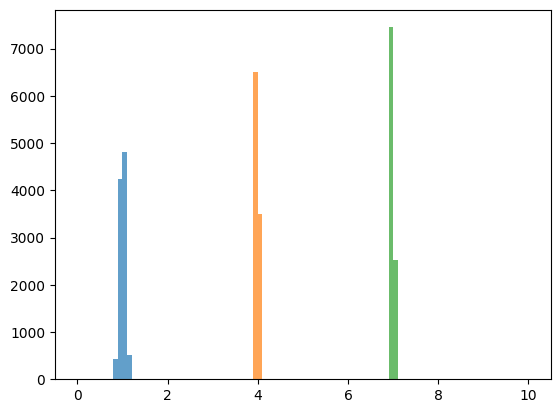

In [25]:
I, μ = Parameterization(K=optimal_K).unpack(
    runs[best_run].exchange_result.samples_by_temperature[-1]
)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, axis=1, indices=key)
μ = np.take_along_axis(μ, axis=1, indices=key)
# σ = np.take_along_axis(σ, axis=1, indices=key)

for i in range(optimal_K):
    plt.hist(μ[:, i], range=(0, 10), bins=100, alpha=0.7)
    print(
        f"μ: {np.nanmean(μ[:, i]):.3f}±{np.nanstd(μ[:, i]):.3f};"  # σ: {np.nanmean(σ[:, i]):.3f}±{np.nanstd(σ[:, i]):.2f}"
    )

center: 1.00, height: 0.44
center: 3.99, height: 0.90
center: 6.98, height: 0.91


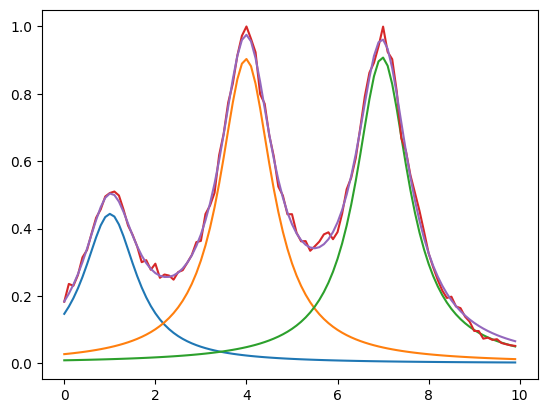

In [26]:
evals = []
for i in range(optimal_K):
    Ii = np.nanmean(I[:, i])
    μi = np.nanmean(μ[:, i])
    # σi = np.nanmean(σ[:, i])
    print(f"center: {μi:.2f}, height: {Ii:.2f}")
    trace = lorentzian(DET_AX, μi, 0.5, 1)
    trace /= trace.max()
    trace *= Ii
    evals.append(trace)
    plt.plot(DET_AX, trace)

plt.plot(DET_AX, y)
plt.plot(DET_AX, np.stack(evals).sum(axis=0))

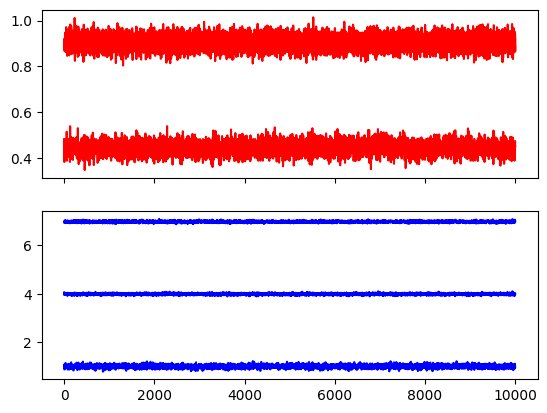

In [27]:
states = runs[best_run].exchange_result.samples_by_temperature[-1]
I, μ = Parameterization(K=optimal_K).unpack(states)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, indices=key, axis=1)
μ = np.take_along_axis(μ, indices=key, axis=1)
# σ = np.take_along_axis(σ, indices=key, axis=1)

fig, (tax, bax) = plt.subplots(nrows=2, sharex=True)

tax.plot(
    I,
    label="amplitudes",
    color="red",
)
bax.plot(
    μ,
    label="centers",
    color="blue",
)